# Treinamento com Transfer Learning + Fine-tuning (ResNet18) — Grupo 4

Notebook executado no Google Colab (GPU T4). Duas etapas:

1. **Transfer learning (linear probe):** backbone da ResNet18 congelado, apenas a camada final treinada. Resultado: 58,7% de acurácia no teste.
2. **Fine-tuning:** últimas camadas (`layer4` + `fc`) destravadas e ajustadas com taxa de aprendizado baixa. Resultado: **63,4% de acurácia no teste** (melhor modelo).

Este notebook complementa o código-fonte principal em `src/`, que também oferece uma versão de CNN treinada do zero (`--model scratch`), utilizável sem GPU.

In [1]:
import torch
print("GPU disponível:", torch.cuda.is_available())
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU disponível: True
Dispositivo: Tesla T4


In [2]:
!pip install -q scikit-learn matplotlib pillow

In [3]:
from google.colab import files

print("Selecione o arquivo .zip baixado do Kaggle (space-images-category)")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
!unzip -q "{zip_name}" -d raw_dataset
!find raw_dataset -maxdepth 2 -type d

Selecione o arquivo .zip baixado do Kaggle (space-images-category)


Saving archive.zip to archive.zip
raw_dataset
raw_dataset/space images
raw_dataset/space images/cosmos space - Google Search
raw_dataset/space images/constellation - Google Search
raw_dataset/space images/nebula - Google Search
raw_dataset/space images/planets - Google Search
raw_dataset/space images/stars - Google Search
raw_dataset/space images/galaxies - Google Search


In [4]:
import os, random, shutil

random.seed(42)

# Ajuste esse caminho se a pasta extraída tiver outro nome (confira a saída da célula anterior)
RAW_DIR = "raw_dataset/space images"
OUT_DIR = "data"

FOLDER_MAPPING = {
    "constellation - Google Search": "constellations",
    "cosmos space - Google Search": "cosmos",
    "galaxies - Google Search": "galaxies",
    "nebula - Google Search": "nebulae",
    "planets - Google Search": "planets",
    "stars - Google Search": "stars",
}

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
TRAIN_RATIO, VAL_RATIO = 0.70, 0.15

for folder_name in os.listdir(RAW_DIR):
    folder_path = os.path.join(RAW_DIR, folder_name)
    if not os.path.isdir(folder_path):
        continue

    class_name = FOLDER_MAPPING.get(folder_name, folder_name.lower().strip())
    files_list = [f for f in os.listdir(folder_path) if os.path.splitext(f)[1].lower() in VALID_EXTS]
    random.shuffle(files_list)

    n = len(files_list)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    splits = {
        "train": files_list[:n_train],
        "val": files_list[n_train:n_train + n_val],
        "test": files_list[n_train + n_val:],
    }

    for split, flist in splits.items():
        out_class_dir = os.path.join(OUT_DIR, split, class_name)
        os.makedirs(out_class_dir, exist_ok=True)
        for i, f in enumerate(flist):
            ext = os.path.splitext(f)[1].lower()
            shutil.copy(os.path.join(folder_path, f), os.path.join(out_class_dir, f"{class_name}_{i:04d}{ext}"))

    print(f"{class_name}: train={len(splits['train'])} val={len(splits['val'])} test={len(splits['test'])}")

cosmos: train=116 val=24 test=26
constellations: train=128 val=27 test=28
nebulae: train=118 val=25 test=27
planets: train=123 val=26 test=27
stars: train=122 val=26 test=27
galaxies: train=165 val=35 test=37


In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 128
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder("data/train", transform=train_transform)
val_dataset = datasets.ImageFolder("data/val", transform=eval_transform)
test_dataset = datasets.ImageFolder("data/test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Treino:", len(train_dataset), "| Validação:", len(val_dataset), "| Teste:", len(test_dataset))

Classes: ['constellations', 'cosmos', 'galaxies', 'nebulae', 'planets', 'stars']
Treino: 772 | Validação: 163 | Teste: 172


In [6]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

# Congela o backbone pré-treinado
for param in model.parameters():
    param.requires_grad = False

# Substitui a camada final para as 6 classes do problema
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

print(model.fc)

Usando: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 73.8MB/s]


Linear(in_features=512, out_features=6, bias=True)


In [7]:
import time
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()
    running_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train_mode)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if train_mode:
            optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if train_mode:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

EPOCHS = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

start = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "val_acc": val_acc,
        }, "best_model_transfer.pt")

print(f"\nTreinamento concluído em {(time.time()-start)/60:.1f} min. Melhor acurácia de validação: {best_val_acc:.4f}")

Epoch 01/15 | train_loss=1.7867 train_acc=0.2681 | val_loss=1.5426 val_acc=0.3926


Epoch 02/15 | train_loss=1.3951 train_acc=0.4845 | val_loss=1.3344 val_acc=0.4724


Epoch 03/15 | train_loss=1.2311 train_acc=0.5583 | val_loss=1.3038 val_acc=0.5092


Epoch 04/15 | train_loss=1.1887 train_acc=0.5622 | val_loss=1.2299 val_acc=0.5399


Epoch 05/15 | train_loss=1.1012 train_acc=0.5946 | val_loss=1.1937 val_acc=0.5644


...

Epoch 11/15 | train_loss=0.9023 train_acc=0.6865 | val_loss=1.1818 val_acc=0.5460


Epoch 12/15 | train_loss=0.8963 train_acc=0.6567 | val_loss=1.1171 val_acc=0.5706


Epoch 13/15 | train_loss=0.8866 train_acc=0.6580 | val_loss=1.1576 val_acc=0.5521


Epoch 14/15 | train_loss=0.8760 train_acc=0.6736 | val_loss=1.1663 val_acc=0.5460


Epoch 15/15 | train_loss=0.8814 train_acc=0.6801 | val_loss=1.1578 val_acc=0.5583

Treinamento concluído em 6.4 min. Melhor acurácia de validação: 0.5706


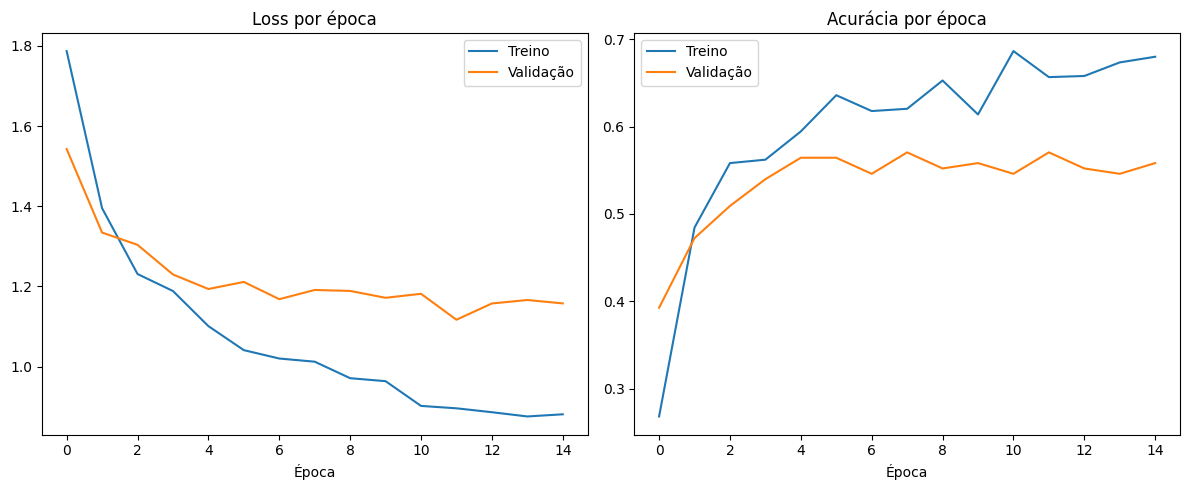

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history["train_loss"], label="Treino")
axes[0].plot(history["val_loss"], label="Validação")
axes[0].set_title("Loss por época"); axes[0].set_xlabel("Época"); axes[0].legend()

axes[1].plot(history["train_acc"], label="Treino")
axes[1].plot(history["val_acc"], label="Validação")
axes[1].set_title("Acurácia por época"); axes[1].set_xlabel("Época"); axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves_transfer.png", dpi=150)
plt.show()

                precision    recall  f1-score   support

constellations     0.7407    0.7143    0.7273        28
        cosmos     0.4444    0.3077    0.3636        26
      galaxies     0.6207    0.4865    0.5455        37
       nebulae     0.5714    0.5926    0.5818        27
       planets     0.6944    0.9259    0.7937        27
         stars     0.4118    0.5185    0.4590        27

      accuracy                         0.5872       172
     macro avg     0.5806    0.5909    0.5785       172
  weighted avg     0.5846    0.5872    0.5787       172



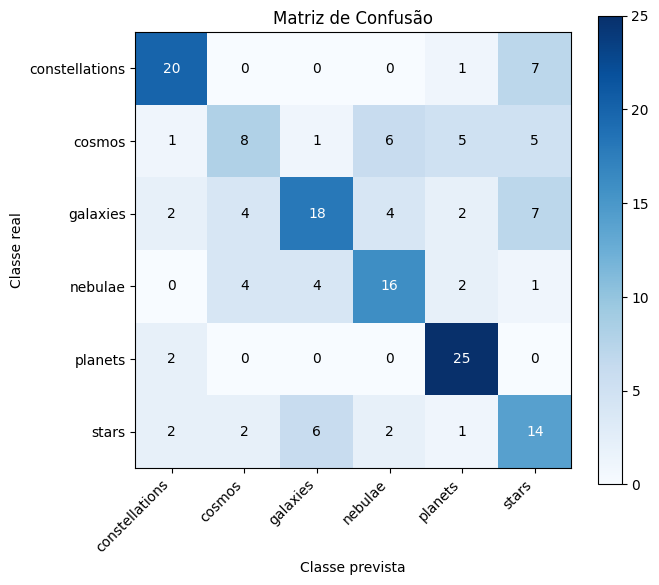


Acurácia final no teste: 0.5872


In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

checkpoint = torch.load("best_model_transfer.pt")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)
with open("classification_report_transfer.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
ax.set_xlabel("Classe prevista"); ax.set_ylabel("Classe real"); ax.set_title("Matriz de Confusão")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_transfer.png", dpi=150)
plt.show()

accuracy = (all_preds == all_labels).mean()
print(f"\nAcurácia final no teste: {accuracy:.4f}")

In [10]:
from google.colab import files

!zip -r resultados_transfer.zip best_model_transfer.pt training_curves_transfer.png confusion_matrix_transfer.png classification_report_transfer.txt
files.download("resultados_transfer.zip")

  adding: best_model_transfer.pt (deflated 7%)
  adding: training_curves_transfer.png (deflated 8%)
  adding: confusion_matrix_transfer.png (deflated 14%)
  adding: classification_report_transfer.txt (deflated 59%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Carrega o melhor modelo já treinado (camada final apenas)
checkpoint = torch.load("best_model_transfer.pt")
model.load_state_dict(checkpoint["model_state_dict"])

# Destrava o último bloco convolucional (layer4) + a camada final (fc)
for name, param in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {trainable:,} de {total:,}")

Parâmetros treináveis: 8,396,806 de 11,179,590


In [12]:
# Taxa de aprendizado bem menor, para não "estragar" o que já foi aprendido
finetune_optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4},
])
finetune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(finetune_optimizer, mode="min", factor=0.5, patience=2)

FT_EPOCHS = 10
ft_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc_ft = checkpoint["val_acc"]  # só salva se melhorar o que já tínhamos
print(f"Acurácia de validação anterior (referência): {best_val_acc_ft:.4f}")

def run_epoch_ft(loader, train_mode):
    model.train() if train_mode else model.eval()
    running_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train_mode)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if train_mode:
            finetune_optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        if train_mode:
            loss.backward()
            finetune_optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

start = time.time()
for epoch in range(1, FT_EPOCHS + 1):
    train_loss, train_acc = run_epoch_ft(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch_ft(val_loader, train_mode=False)
    finetune_scheduler.step(val_loss)

    ft_history["train_loss"].append(train_loss)
    ft_history["train_acc"].append(train_acc)
    ft_history["val_loss"].append(val_loss)
    ft_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{FT_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "val_acc": val_acc,
        }, "best_model_transfer_finetuned.pt")
        print(f"  → Novo melhor modelo salvo! ({val_acc:.4f})")

print(f"\nFine-tuning concluído em {(time.time()-start)/60:.1f} min. Melhor acurácia de validação: {best_val_acc_ft:.4f}")

Acurácia de validação anterior (referência): 0.5706


Epoch 01/10 | train_loss=0.9588 train_acc=0.6516 | val_loss=1.1664 val_acc=0.5890
  → Novo melhor modelo salvo! (0.5890)


Epoch 02/10 | train_loss=0.9049 train_acc=0.6723 | val_loss=1.1129 val_acc=0.5951
  → Novo melhor modelo salvo! (0.5951)


Epoch 03/10 | train_loss=0.8641 train_acc=0.7021 | val_loss=1.1101 val_acc=0.5460


Epoch 04/10 | train_loss=0.8131 train_acc=0.7047 | val_loss=1.1075 val_acc=0.5521


...

Epoch 06/10 | train_loss=0.7876 train_acc=0.7124 | val_loss=1.0973 val_acc=0.5767


Epoch 07/10 | train_loss=0.7204 train_acc=0.7358 | val_loss=1.1001 val_acc=0.5460


Epoch 08/10 | train_loss=0.6921 train_acc=0.7655 | val_loss=1.0857 val_acc=0.5706


Epoch 09/10 | train_loss=0.6898 train_acc=0.7655 | val_loss=1.0645 val_acc=0.5828


Epoch 10/10 | train_loss=0.6640 train_acc=0.7591 | val_loss=1.0699 val_acc=0.6074
  → Novo melhor modelo salvo! (0.6074)

Fine-tuning concluído em 4.3 min. Melhor acurácia de validação: 0.6074


                precision    recall  f1-score   support

constellations     0.7692    0.7143    0.7407        28
        cosmos     0.5000    0.3846    0.4348        26
      galaxies     0.6047    0.7027    0.6500        37
       nebulae     0.6296    0.6296    0.6296        27
       planets     0.8276    0.8889    0.8571        27
         stars     0.4444    0.4444    0.4444        27

      accuracy                         0.6337       172
     macro avg     0.6293    0.6274    0.6261       172
  weighted avg     0.6294    0.6337    0.6293       172



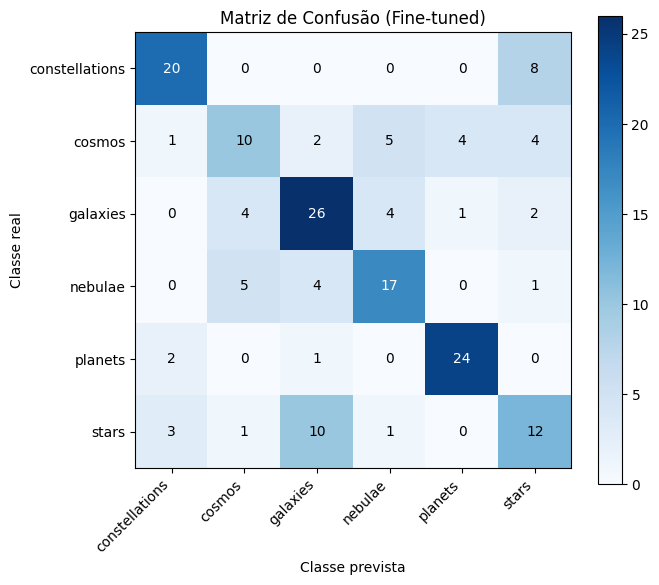


Acurácia final no teste (fine-tuned): 0.6337
Acurácia anterior (backbone congelado): 0.5581


In [13]:
checkpoint_ft = torch.load("best_model_transfer_finetuned.pt")
model.load_state_dict(checkpoint_ft["model_state_dict"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

report_ft = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report_ft)
with open("classification_report_finetuned.txt", "w") as f:
    f.write(report_ft)

cm_ft = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_ft, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
ax.set_xlabel("Classe prevista"); ax.set_ylabel("Classe real"); ax.set_title("Matriz de Confusão (Fine-tuned)")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, str(cm_ft[i, j]), ha="center", va="center",
                color="white" if cm_ft[i, j] > cm_ft.max()/2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix_finetuned.png", dpi=150)
plt.show()

accuracy_ft = (all_preds == all_labels).mean()
print(f"\nAcurácia final no teste (fine-tuned): {accuracy_ft:.4f}")
print(f"Acurácia anterior (backbone congelado): 0.5581")

In [14]:
from google.colab import files
!zip -r resultados_finetuned.zip best_model_transfer_finetuned.pt confusion_matrix_finetuned.png classification_report_finetuned.txt
files.download("resultados_finetuned.zip")

  adding: best_model_transfer_finetuned.pt (deflated 7%)
  adding: confusion_matrix_finetuned.png (deflated 14%)
  adding: classification_report_finetuned.txt (deflated 62%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>